In [15]:
import pandas as pd

forecast = pd.read_csv("../data/cleaned/2025_investment_forecast.csv")
ranking = pd.read_csv("../data/cleaned/investment_ranking_updated.csv")

In [16]:
forecast["country"] = forecast["country"].str.strip()
ranking["country"] = ranking["country"].str.strip()

In [17]:
final_model = forecast.merge(
    ranking,
    on="country",
    how="left"
)

In [18]:
#creating future growth score
def normalize_positive(series):
    return (series - series.min()) / (series.max() - series.min()) * 100

final_model["future_growth_score"] = normalize_positive(
    final_model["forecast_2025_price"]
)

In [21]:
final_model["investment_score"] = final_model["investment_score_y"]

In [20]:
final_model.columns

Index(['country', 'nominal_house_price_index', 'cagr', 'forecast_2025_price',
       'year_x', 'nominal_price_total_growth_pct_x', 'rent_total_growth_pct_x',
       'price_to_income_ratio_x', 'price_to_rent_ratio_x',
       'average_annual_wage_x', 'household_disposable_income_x',
       'interest_rate_x', 'population_growth_x', 'growth_score_x',
       'rent_score_x', 'affordability_score_x', 'interest_score_x',
       'demand_score_x', 'investment_score_x', 'recommendation_x', 'year_y',
       'nominal_price_total_growth_pct_y', 'rent_total_growth_pct_y',
       'price_to_income_ratio_y', 'price_to_rent_ratio_y',
       'average_annual_wage_y', 'household_disposable_income_y',
       'interest_rate_y', 'population_growth_y', 'growth_score_y',
       'rent_score_y', 'affordability_score_y', 'interest_score_y',
       'demand_score_y', 'investment_score_y', 'recommendation_y',
       'future_growth_score'],
      dtype='str')

In [24]:
final_model["final_score"] = (
    final_model["investment_score"] * 0.6 +
    final_model["future_growth_score"] * 0.4
)

In [25]:
final_model = final_model.sort_values("final_score", ascending=False)

final_model[[
    "country",
    "investment_score",
    "future_growth_score",
    "final_score"
]]

,country,investment_score,future_growth_score,final_score
0,Portugal,65.508359,100.000000,79.305016
3,Austria,79.605504,34.077154,61.394164
2,Netherlands,59.728802,55.126684,57.887955
1,Poland,41.741134,61.426338,49.615216
5,Germany,61.268342,26.107740,47.204101
6,Sweden,59.799323,13.116535,41.126208
4,Spain,41.391210,28.153452,36.096107
7,France,43.777185,7.888670,29.421779
8,Italy,32.973187,0.000000,19.783912


In [26]:
def final_recommendation(score):
    if score >= 75:
        return "Strong Buy (High Confidence)"
    elif score >= 60:
        return "Buy (Good Potential)"
    elif score >= 45:
        return "Neutral / Watchlist"
    else:
        return "Avoid / High Risk"

final_model["final_recommendation"] = final_model["final_score"].apply(final_recommendation)

In [27]:
final_result = final_model[[
    "country",
    "investment_score",
    "future_growth_score",
    "final_score",
    "final_recommendation"
]]

final_result

,country,investment_score,future_growth_score,final_score,final_recommendation
0,Portugal,65.508359,100.000000,79.305016,Strong Buy (High Confidence)
3,Austria,79.605504,34.077154,61.394164,Buy (Good Potential)
2,Netherlands,59.728802,55.126684,57.887955,Neutral / Watchlist
1,Poland,41.741134,61.426338,49.615216,Neutral / Watchlist
5,Germany,61.268342,26.107740,47.204101,Neutral / Watchlist
6,Sweden,59.799323,13.116535,41.126208,Avoid / High Risk
4,Spain,41.391210,28.153452,36.096107,Avoid / High Risk
7,France,43.777185,7.888670,29.421779,Avoid / High Risk
8,Italy,32.973187,0.000000,19.783912,Avoid / High Risk


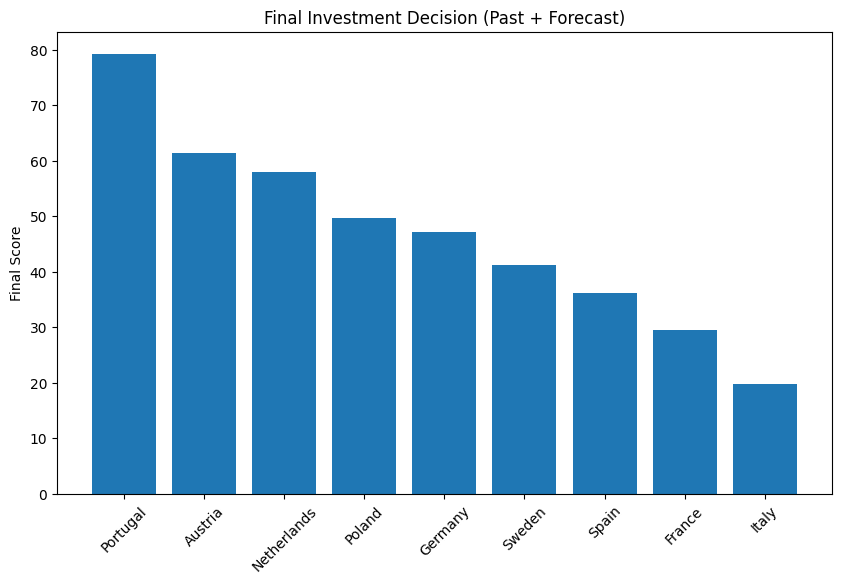

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(final_result["country"], final_result["final_score"])

plt.xticks(rotation=45)
plt.title("Final Investment Decision (Past + Forecast)")
plt.ylabel("Final Score")

plt.show()

📊 **Why Portugal Becomes the Top Recommendation in the Final Model**

Initially, Austria ranked as the strongest investment opportunity based on historical and current performance indicators such as price stability, affordability, and overall investment score.

However, after incorporating the 2025 forecast into the model, Portugal emerges as the leading recommendation. This shift is driven by the inclusion of forward-looking growth potential, captured through the forecasted housing price index and translated into a future growth score.

The final model combines:

60% weight on current investment conditions (investment_score)
40% weight on future potential (future_growth_score)

While Austria maintains strong fundamentals and stability, Portugal demonstrates higher projected growth based on its historical price momentum (CAGR). As a result, Portugal’s stronger future outlook outweighs Austria’s current advantage when both dimensions are considered together.

This outcome reflects a key principle in investment analysis:

Markets with higher growth potential can outperform currently strong but slower-growing markets when future expectations are incorporated.

Therefore, Portugal is identified as the most attractive opportunity when balancing both present conditions and expected future performance.

In [31]:
final_result.to_csv("../data/cleaned/final_future_investment_decision.csv", index=False)